## 5.3.1 Segmentation couleur HSV

On applique un masque HSV sur les frames capturées par la caméra
OV5647 pour isoler les pixels d'eau de la rivière.

**Pourquoi HSV et pas RGB ?**
L'espace HSV sépare la teinte (Hue) de la luminosité (Value),
ce qui le rend robuste aux changements d'éclairage extérieur
(soleil, nuages, nuit). En RGB, la même couleur d'eau peut avoir
des valeurs très différentes selon la lumière.

**Plage HSV utilisée :**
- Hue : 85 → 135 (bleu-vert correspondant à l'eau)
- Saturation : 40 → 255
- Value : 40 → 255

Pixels totaux  : 307200
Pixels eau     : 61216
Ratio eau      : 19.93%
✅  Niveau d'eau NORMAL


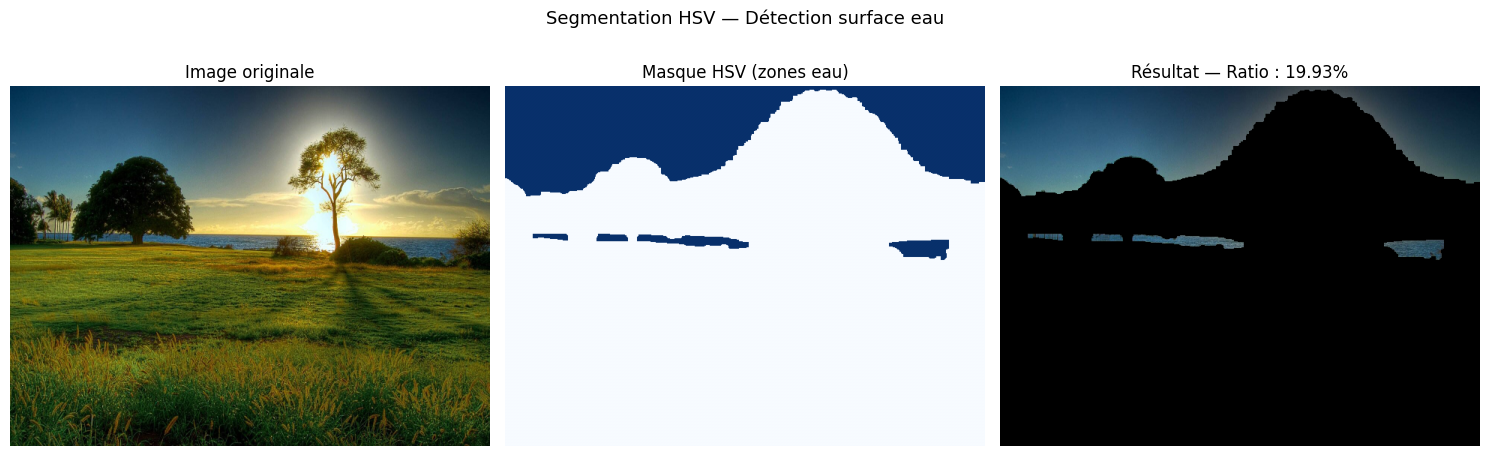

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Chargement image rivière
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1a/24701-nature-natural-beauty.jpg/1280px-24701-nature-natural-beauty.jpg"

# To avoid 403 Forbidden error, add a User-Agent header
opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)
urllib.request.urlretrieve(url, "river.jpg")

frame = cv2.imread("river.jpg")
frame = cv2.resize(frame, (640, 480))

# Conversion BGR → HSV
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

# Plage HSV pour détecter l'eau
# Ajuster ces valeurs selon la couleur réelle de votre rivière
lower_water = np.array([85,  40,  40])
upper_water = np.array([135, 255, 255])

# Application masque
mask = cv2.inRange(hsv, lower_water, upper_water)

# Nettoyage du masque (suppression bruit)
kernel     = np.ones((5, 5), np.uint8)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)

# Application masque sur image originale
result = cv2.bitwise_and(frame, frame, mask=mask_clean)

# Calcul ratio eau
total_pixels = mask_clean.shape[0] * mask_clean.shape[1]
water_pixels = cv2.countNonZero(mask_clean)
water_ratio  = round(water_pixels / total_pixels, 4)

print("=" * 40)
print(f"Pixels totaux  : {total_pixels}")
print(f"Pixels eau     : {water_pixels}")
print(f"Ratio eau      : {water_ratio * 100:.2f}%")
if water_ratio > 0.5:
    print("⚠️  Niveau d'eau ÉLEVÉ")
elif water_ratio > 0.3:
    print("🟡  Niveau d'eau MODÉRÉ")
else:
    print("✅  Niveau d'eau NORMAL")
print("=" * 40)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Segmentation HSV — Détection surface eau", fontsize=13)

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Image originale")
axes[0].axis("off")

axes[1].imshow(mask_clean, cmap="Blues")
axes[1].set_title("Masque HSV (zones eau)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Résultat — Ratio : {water_ratio*100:.2f}%")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("hsv_result.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.3.2 Optical Flow

L'algorithme de Lucas-Kanade suit le déplacement de points
caractéristiques entre deux frames consécutives pour estimer
la vitesse d'écoulement de l'eau.

**Pourquoi Lucas-Kanade ?**
C'est l'algorithme Optical Flow le plus léger et le plus rapide,
parfaitement adapté au Raspberry Pi. Il suppose que les pixels
voisins ont un mouvement similaire — hypothèse valide pour
une surface d'eau en mouvement.

**Formule vitesse :**
vitesse (m/s) = (déplacement_pixels × fps) / pixels_par_mètre

Points suivis      : 12
Déplacement moyen  : 4.47 px/frame
Vitesse courant    : 2.683 m/s
🟡  Courant MODÉRÉ


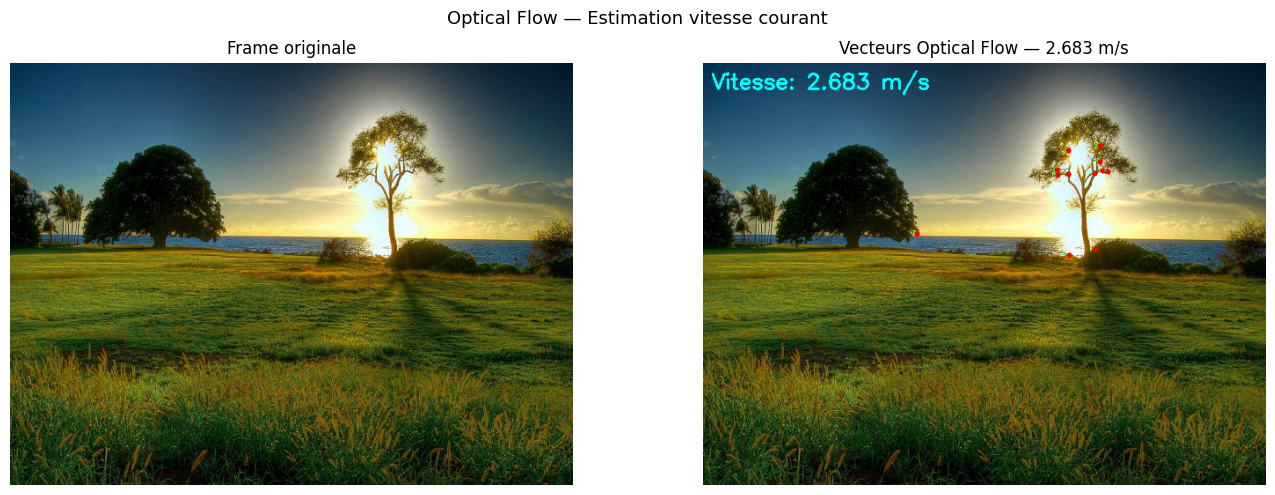

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Chargement et simulation 2 frames
# En conditions réelles : frame1 et frame2 viennent du flux caméra
frame1 = cv2.imread("river.jpg")
frame1 = cv2.resize(frame1, (640, 480))

# Simulation frame2 : translation de 4px pour simuler courant
M      = np.float32([[1, 0, 4], [0, 1, 2]])
frame2 = cv2.warpAffine(frame1, M, (640, 480))

# Conversion niveaux de gris
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

# Détection points caractéristiques (Shi-Tomasi)
# Ces points sont suivis entre les deux frames
feature_params = dict(
    maxCorners  = 100,   # max 100 points suivis
    qualityLevel= 0.3,   # qualité minimale du point
    minDistance = 7,     # distance min entre points
    blockSize   = 7
)
points1 = cv2.goodFeaturesToTrack(gray1, mask=None, **feature_params)

# Calcul Optical Flow Lucas-Kanade
lk_params = dict(
    winSize  = (15, 15),
    maxLevel = 2,
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)
points2, status, _ = cv2.calcOpticalFlowPyrLK(
    gray1, gray2, points1, None, **lk_params
)

# Filtrage points bien suivis
good_old = points1[status == 1]
good_new = points2[status == 1]

# Calcul vitesse
distances      = np.sqrt(
    (good_new[:, 0] - good_old[:, 0])**2 +
    (good_new[:, 1] - good_old[:, 1])**2
)
fps            = 30       # fps caméra OV5647
pixels_per_m   = 50       # calibration : 50px = 1m (à ajuster sur site)
avg_speed_px   = np.mean(distances)
avg_speed_ms   = (avg_speed_px * fps) / pixels_per_m

print("=" * 40)
print(f"Points suivis      : {len(good_new)}")
print(f"Déplacement moyen  : {avg_speed_px:.2f} px/frame")
print(f"Vitesse courant    : {avg_speed_ms:.3f} m/s")
if avg_speed_ms > 3.0:
    print("⚠️  Courant DANGEREUX")
elif avg_speed_ms > 1.5:
    print("🟡  Courant MODÉRÉ")
else:
    print("✅  Courant NORMAL")
print("=" * 40)

# Visualisation vecteurs mouvement
vis = frame1.copy()
for new, old in zip(good_new, good_old):
    a, b = new.ravel().astype(int)
    c, d = old.ravel().astype(int)
    cv2.arrowedLine(vis, (c, d), (a, b), (0, 255, 0), 2, tipLength=0.4)
    cv2.circle(vis, (a, b), 3, (0, 0, 255), -1)

cv2.putText(
    vis,
    f"Vitesse: {avg_speed_ms:.3f} m/s",
    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optical Flow — Estimation vitesse courant", fontsize=13)

axes[0].imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
axes[0].set_title("Frame originale")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Vecteurs Optical Flow — {avg_speed_ms:.3f} m/s")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("optical_flow_result.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.3.3 Prétraitement des images

Avant d'envoyer les frames aux modèles IA, on applique
3 opérations de prétraitement pour améliorer la qualité :
1. Redimensionnement → 640×480
2. CLAHE → correction luminosité (utile nuit/jour nuageux)
3. Filtre gaussien → suppression bruit caméra

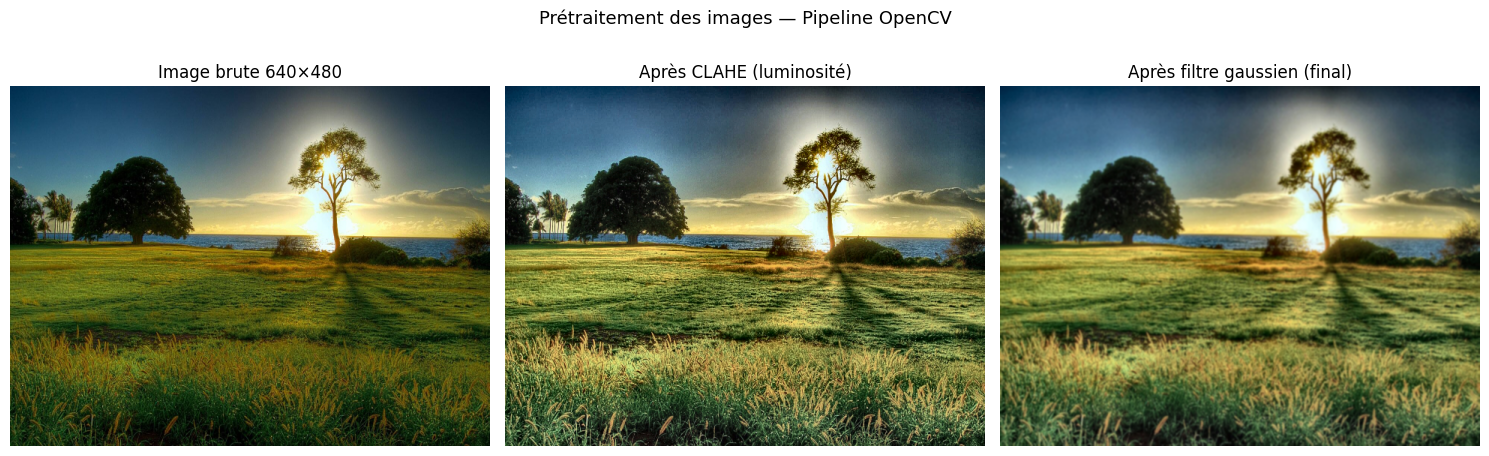

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Chargement image ─────────────────────────────────────────────
frame = cv2.imread("river.jpg")

# ── Étape 1 : Redimensionnement ──────────────────────────────────
frame_resized = cv2.resize(frame, (640, 480))

# ── Étape 2 : CLAHE (correction luminosité) ──────────────────────
# Convertir en LAB pour appliquer CLAHE sur canal L uniquement
lab   = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l_eq  = clahe.apply(l)
lab_eq = cv2.merge((l_eq, a, b))
frame_clahe = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

# ── Étape 3 : Filtre gaussien (réduction bruit) ──────────────────
frame_final = cv2.GaussianBlur(frame_clahe, (5, 5), 0)

# ── Visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Prétraitement des images — Pipeline OpenCV", fontsize=13)

axes[0].imshow(cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB))
axes[0].set_title("Image brute 640×480")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(frame_clahe, cv2.COLOR_BGR2RGB))
axes[1].set_title("Après CLAHE (luminosité)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(frame_final, cv2.COLOR_BGR2RGB))
axes[2].set_title("Après filtre gaussien (final)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("preprocessing_result.png", dpi=150, bbox_inches="tight")
plt.show()
